# 03 — Data Preparation

**Project:** Forecasting the Effects of Exchange Rate Fluctuations on US Trade Flows  
**Phase:** CRISP-DM 3 — Data Preparation  
**Author:** Francisco Giordano Rigon  

---

## Objective

Transform all raw data collected in Phase 2 into a clean, aligned, and feature-rich dataset ready for modeling.

## Steps

1. **Load** all raw datasets
2. **Frequency alignment** — convert all series to monthly
3. **Variable selection** — keep only confirmed independent variables
4. **Target variable** — process trade flows (monthly total + sectoral proportions)
5. **Integration** — merge features with target into one master DataFrame per country pair
6. **Cleaning** — missing values, duplicates, temporal integrity
7. **Outlier detection** — IQR method + economic crisis dummies
8. **Transformations** — log, differencing, normalization
9. **Feature engineering** — lags, moving averages, calendar features
10. **Save** final datasets to `data/processed/`

## Modeling window

Monthly data: **2010-01 to 2024-12** (180 months)  
Country pairs: USA ↔ Canada, USA ↔ Mexico, USA ↔ Brazil  
Sectors: Commodities, Manufactured Goods, High-Tech  
Directions: Exports (X) + Imports (M)

---

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Paths
RAW   = Path('../data/raw')
PROC  = Path('../data/processed')
FIGS  = Path('../reports/figures')
PROC.mkdir(exist_ok=True)

# Modeling window
START = '2010-01-01'
END   = '2024-12-31'

# Country pairs
PARTNERS = {
    'CAN': {'iso': 'CAN', 'name': 'Canada',  'fx': 'DEXCAUS'},
    'MEX': {'iso': 'MEX', 'name': 'Mexico',  'fx': 'DEXMXUS'},
    'BRA': {'iso': 'BRA', 'name': 'Brazil',  'fx': 'DEXBZUS'},
}

# HS2 sectoral classification (aligned with TCC1 Section 2.3.2)
SECTOR_MAP = {
    'Commodities':       list(range(1, 16)) + [25, 26, 27, 41, 43, 44, 45, 46, 47, 71, 72],
    'High-Tech':         [30, 84, 85, 88, 90, 91],
    'Manufactured Goods': None,  # all remaining — assigned below
}

print('Setup complete.')
print(f'Modeling window: {START[:7]} → {END[:7]}')

Setup complete.
Modeling window: 2010-01 → 2024-12


---

## 1. Load Raw Data

In [2]:
# Helper: load a FRED CSV and parse the date index (column 'Unnamed: 0')
def load_fred(filename: str) -> pd.DataFrame:
    """Load a FRED CSV and return a DataFrame with a DatetimeIndex."""
    df = pd.read_csv(RAW / filename, index_col=0, parse_dates=True)
    df.index.name = 'date'
    return df

# Load all FRED files
df_fx       = load_fred('fred_exchange_rates.csv')   # daily: DEXCAUS, DEXMXUS, DEXBZUS
df_macro    = load_fred('fred_macro.csv')            # mixed: FEDFUNDS, CPIAUCSL, GDPC1, UNRATE, INDPRO
df_reer     = load_fred('fred_reer.csv')             # monthly: REER_USA, REER_CAN, REER_MEX, REER_BRA
df_rates    = load_fred('fred_rates_partners.csv')   # monthly: RATE_CAN, RATE_MEX_3M, RATE_BRA
df_cpi      = load_fred('fred_cpi_partners.csv')     # monthly: CPI_CAN, CPI_MEX, CPI_BRA
df_gdp      = load_fred('fred_gdp_partners.csv')     # quarterly: GDP_CAN, GDP_MEX, GDP_BRA
df_indpro   = load_fred('fred_indpro_partners.csv')  # monthly: Canada, Mexico, Brazil
df_comm     = load_fred('fred_commodities.csv')      # mixed: DCOILWTICO (daily), PSOYBUSDM, PIORECRUSDM (monthly)

# Comtrade
df_trade_m  = pd.read_csv(RAW / 'comtrade_monthly_total.csv')   # monthly totals 2010-2024
df_trade_a  = pd.read_csv(RAW / 'comtrade_annual_hs2.csv')      # annual by HS2 sector 2000-2024

print('All raw files loaded.')
print(f'  FX rates:         {df_fx.shape}')
print(f'  Macro USA:        {df_macro.shape}')
print(f'  REER:             {df_reer.shape}')
print(f'  Partner rates:    {df_rates.shape}')
print(f'  Partner CPI:      {df_cpi.shape}')
print(f'  Partner GDP:      {df_gdp.shape}')
print(f'  Partner IndPro:   {df_indpro.shape}')
print(f'  Commodities:      {df_comm.shape}')
print(f'  Trade monthly:    {df_trade_m.shape}')
print(f'  Trade annual HS2: {df_trade_a.shape}')

All raw files loaded.
  FX rates:         (6840, 3)
  Macro USA:        (314, 5)
  REER:             (314, 4)
  Partner rates:    (314, 3)
  Partner CPI:      (304, 3)
  Partner GDP:      (104, 3)
  Partner IndPro:   (291, 3)
  Commodities:      (6932, 3)
  Trade monthly:    (1080, 47)
  Trade annual HS2: (14513, 47)


---

## 2. Frequency Alignment — Convert Everything to Monthly

We have three different frequencies in our raw data:

| Frequency | Variables | Action |
|-----------|-----------|--------|
| Daily | DEXCAUS, DEXMXUS, DEXBZUS, DCOILWTICO | Monthly **mean** |
| Quarterly | GDPC1, GDP_CAN, GDP_MEX, GDP_BRA | **Forward-fill** to monthly |
| Monthly | All others | Already aligned |

**Why monthly mean for exchange rates?**  
Trade flows are measured monthly. Using the average exchange rate over the month better represents the "average price" importers and exporters faced during that month.

**Why forward-fill for GDP?**  
GDP is published quarterly. We carry the last known quarterly value forward for each month within that quarter — the standard approach in time series econometrics. Linear interpolation is another option but forward-fill avoids using "future" quarterly data before it's published (no look-ahead bias).

In [3]:
# --- 2.1 Daily → Monthly mean ---

# Exchange rates: monthly mean of daily observations
# 'MS' = Month Start frequency (first day of each month)
fx_monthly = df_fx.resample('MS').mean()
fx_monthly.columns = ['FX_USD_CAD', 'FX_USD_MXN', 'FX_USD_BRL']

# WTI crude oil: monthly mean (other commodity series are already monthly)
wti_monthly = df_comm[['DCOILWTICO']].resample('MS').mean()
wti_monthly.columns = ['WTI_oil']

# Soybean and Iron Ore: already monthly, just resample to align index format
comm_monthly = df_comm[['PSOYBUSDM', 'PIORECRUSDM']].resample('MS').mean()
comm_monthly.columns = ['Soybean', 'Iron_ore']

print('Daily → Monthly (mean):')
print(f'  FX monthly:       {fx_monthly.shape}')
print(f'  WTI monthly:      {wti_monthly.shape}')

Daily → Monthly (mean):
  FX monthly:       (315, 3)
  WTI monthly:      (315, 1)


In [4]:
# --- 2.2 Quarterly → Monthly (forward fill) ---

# US GDP: quarterly → monthly forward fill
# First resample to monthly (this creates NaN for non-quarter months),
# then forward-fill those NaN values.
gdp_usa_monthly = (
    df_macro[['GDPC1']]
    .resample('MS').first()  # keep only the value at the start of each month
    .ffill()                 # carry the quarterly value forward 2 months
)
gdp_usa_monthly.columns = ['GDP_USA']

# Partner GDP: same treatment
gdp_partners_monthly = (
    df_gdp
    .resample('MS').first()
    .ffill()
)
gdp_partners_monthly.columns = ['GDP_CAN', 'GDP_MEX', 'GDP_BRA']

print('Quarterly → Monthly (forward fill):')
print(f'  GDP USA monthly:      {gdp_usa_monthly.shape}')
print(f'  GDP partners monthly: {gdp_partners_monthly.shape}')

# Verify: forward fill worked correctly
print(f'\nGDP_USA missing after ffill: {gdp_usa_monthly["GDP_USA"].isna().sum()}')
print(f'GDP partners missing after ffill: {gdp_partners_monthly.isna().sum().sum()}')

Quarterly → Monthly (forward fill):
  GDP USA monthly:      (314, 1)
  GDP partners monthly: (310, 3)

GDP_USA missing after ffill: 0
GDP partners missing after ffill: 0


In [5]:
# --- 2.3 Already monthly — align to Month Start index ---

macro_monthly = df_macro[['FEDFUNDS', 'CPIAUCSL', 'UNRATE', 'INDPRO']].resample('MS').first()
macro_monthly.columns = ['FEDFUNDS', 'CPI_USA', 'UNRATE_USA', 'INDPRO_USA']

reer_monthly   = df_reer.resample('MS').first()
rates_monthly  = df_rates.resample('MS').first()
cpi_monthly    = df_cpi.resample('MS').first()

# Rename partner IndPro columns (raw has country names)
indpro_monthly = df_indpro.resample('MS').first()
indpro_monthly.columns = ['INDPRO_CAN', 'INDPRO_MEX', 'INDPRO_BRA']

print('Monthly series aligned to Month Start:')
print(f'  Macro USA:        {macro_monthly.shape}')
print(f'  REER:             {reer_monthly.shape}')
print(f'  Partner rates:    {rates_monthly.shape}')
print(f'  Partner CPI:      {cpi_monthly.shape}')
print(f'  Partner IndPro:   {indpro_monthly.shape}')

Monthly series aligned to Month Start:
  Macro USA:        (314, 4)
  REER:             (314, 4)
  Partner rates:    (314, 3)
  Partner CPI:      (304, 3)
  Partner IndPro:   (291, 3)


---

## 3. Build Master Feature DataFrame

We now join all feature series into a single DataFrame covering 2010-01 to 2024-12.

These features are **country-pair agnostic** — the same macro variables apply to all three country pairs. Country-specific exchange rates are included for all three pairs and will be split later during modeling.

In [6]:
# Concatenate all feature DataFrames along columns
features = pd.concat([
    fx_monthly,           # FX_USD_CAD, FX_USD_MXN, FX_USD_BRL
    reer_monthly,         # REER_USA, REER_CAN, REER_MEX, REER_BRA
    macro_monthly,        # FEDFUNDS, CPI_USA, UNRATE_USA, INDPRO_USA
    gdp_usa_monthly,      # GDP_USA
    rates_monthly,        # RATE_CAN, RATE_MEX_3M, RATE_BRA
    cpi_monthly,          # CPI_CAN, CPI_MEX, CPI_BRA
    gdp_partners_monthly, # GDP_CAN, GDP_MEX, GDP_BRA
    indpro_monthly,       # INDPRO_CAN, INDPRO_MEX, INDPRO_BRA
    wti_monthly,          # WTI_oil
    comm_monthly,         # Soybean, Iron_ore
], axis=1)

# Filter to our modeling window
features = features.loc[START:END]

print(f'Master feature DataFrame: {features.shape}')
print(f'  Rows (months): {len(features)}')
print(f'  Columns (features): {len(features.columns)}')
print(f'  Date range: {features.index[0].strftime("%Y-%m")} → {features.index[-1].strftime("%Y-%m")}')
print()
print('Columns:', features.columns.tolist())

Master feature DataFrame: (180, 27)
  Rows (months): 180
  Columns (features): 27
  Date range: 2010-01 → 2024-12

Columns: ['FX_USD_CAD', 'FX_USD_MXN', 'FX_USD_BRL', 'REER_USA', 'REER_CAN', 'REER_MEX', 'REER_BRA', 'FEDFUNDS', 'CPI_USA', 'UNRATE_USA', 'INDPRO_USA', 'GDP_USA', 'RATE_CAN', 'RATE_MEX_3M', 'RATE_BRA', 'CPI_CAN', 'CPI_MEX', 'CPI_BRA', 'GDP_CAN', 'GDP_MEX', 'GDP_BRA', 'INDPRO_CAN', 'INDPRO_MEX', 'INDPRO_BRA', 'WTI_oil', 'Soybean', 'Iron_ore']


---

## 4. Target Variable — Trade Flows

### 4.1 Monthly total trade flows

The `comtrade_monthly_total.csv` has aggregate trade values (all HS chapters combined) for each country pair, direction (X/M), and month.

### 4.2 Sectoral disaggregation

Monthly data by HS2 sector is **not available** from UN Comtrade Plus (monthly data is only available as aggregates). To enable sectoral modeling, we use the following approach:

1. From annual HS2 data, calculate the **proportion** of each sector (Commodities / Manufactured Goods / High-Tech) within total annual trade, per country pair and per year.
2. Apply these annual proportions to the monthly total flows within each year.
3. This yields estimated monthly flows by sector.

**Limitation:** This approach assumes intra-year sector shares are constant, which is a simplification. It will be documented as a methodological limitation in the thesis.

In [7]:
# --- 4.1 Process monthly total trade flows ---

# Select only the columns we need
trade_m = df_trade_m[['period', 'partnerISO', 'flowCode', 'primaryValue']].copy()

# Convert period (YYYYMM integer) to a proper date (first day of the month)
trade_m['date'] = pd.to_datetime(trade_m['period'].astype(str), format='%Y%m')

# Rename for clarity
trade_m = trade_m.rename(columns={'primaryValue': 'trade_value_usd'})

# Filter to modeling window
trade_m = trade_m[(trade_m['date'] >= START) & (trade_m['date'] <= END)]

# Pivot: one row per month × country pair
# Separate exports (X) and imports (M)
trade_m_exports = trade_m[trade_m['flowCode'] == 'X'].copy()
trade_m_imports = trade_m[trade_m['flowCode'] == 'M'].copy()

print('Monthly trade flows (total):')
print(f'  Exports: {trade_m_exports.shape}')
print(f'  Imports: {trade_m_imports.shape}')
print()
print('Partners found:', trade_m['partnerISO'].unique())

Monthly trade flows (total):
  Exports: (540, 5)
  Imports: (540, 5)

Partners found: <StringArray>
['BRA', 'CAN', 'MEX']
Length: 3, dtype: str


In [8]:
# --- 4.2 Compute annual HS2 sector proportions ---

# First, assign each HS2 chapter to a sector
def assign_sector(hs2_code: int) -> str:
    """
    Assign an HS2 chapter to one of three sectors:
    Commodities, High-Tech, or Manufactured Goods.
    
    Args:
        hs2_code: HS2 chapter number (1–97)
    
    Returns:
        Sector name as string
    """
    commodities = list(range(1, 16)) + [25, 26, 27, 41, 43, 44, 45, 46, 47, 71, 72]
    hightech    = [30, 84, 85, 88, 90, 91]
    if hs2_code in commodities:
        return 'Commodities'
    elif hs2_code in hightech:
        return 'High-Tech'
    else:
        return 'Manufactured Goods'

# Apply to annual HS2 dataset
df_trade_a['sector'] = df_trade_a['cmdCode'].astype(int).apply(assign_sector)

# Aggregate annual trade by (year, partner, flow, sector)
annual_by_sector = (
    df_trade_a
    .groupby(['period', 'partnerISO', 'flowCode', 'sector'])['primaryValue']
    .sum()
    .reset_index()
)

# Total annual trade per (year, partner, flow) — to compute proportions
annual_total = (
    annual_by_sector
    .groupby(['period', 'partnerISO', 'flowCode'])['primaryValue']
    .sum()
    .reset_index()
    .rename(columns={'primaryValue': 'annual_total'})
)

# Merge to compute proportion = sector_value / total
annual_by_sector = annual_by_sector.merge(annual_total, on=['period', 'partnerISO', 'flowCode'])
annual_by_sector['sector_share'] = annual_by_sector['primaryValue'] / annual_by_sector['annual_total']

print('Annual sector proportions computed.')
print(f'  Shape: {annual_by_sector.shape}')
print()
# Show example: Brazil exports in 2024
ex = annual_by_sector[
    (annual_by_sector['period'] == 2024) &
    (annual_by_sector['partnerISO'] == 'BRA') &
    (annual_by_sector['flowCode'] == 'X')
][['sector', 'sector_share']]
print('Example — USA exports to Brazil, 2024:')
print(ex.to_string(index=False))

Annual sector proportions computed.
  Shape: (450, 7)

Example — USA exports to Brazil, 2024:
            sector  sector_share
       Commodities      0.192551
         High-Tech      0.498280
Manufactured Goods      0.309169


In [9]:
# --- 4.3 Apply annual proportions to monthly totals ---

# Add year to monthly trade data so we can merge with annual proportions
trade_m['period'] = trade_m['date'].dt.year

# Merge monthly totals with annual sector shares
trade_sectoral = trade_m.merge(
    annual_by_sector[['period', 'partnerISO', 'flowCode', 'sector', 'sector_share']],
    on=['period', 'partnerISO', 'flowCode'],
    how='left'
)

# Estimated monthly sectoral trade = monthly total × annual sector proportion
trade_sectoral['trade_sectoral_usd'] = trade_sectoral['trade_value_usd'] * trade_sectoral['sector_share']

print(f'Monthly sectoral trade estimates: {trade_sectoral.shape}')
print(f'Missing values in trade_sectoral_usd: {trade_sectoral["trade_sectoral_usd"].isna().sum()}')
print()
# Show one row per sector for a single month
sample = trade_sectoral[
    (trade_sectoral['date'] == '2020-01-01') &
    (trade_sectoral['partnerISO'] == 'CAN') &
    (trade_sectoral['flowCode'] == 'X')
][['date', 'partnerISO', 'flowCode', 'sector', 'trade_value_usd', 'sector_share', 'trade_sectoral_usd']]
print('Example — USA exports to Canada, Jan 2020:')
print(sample.to_string(index=False))

Monthly sectoral trade estimates: (3240, 8)
Missing values in trade_sectoral_usd: 0

Example — USA exports to Canada, Jan 2020:
      date partnerISO flowCode             sector  trade_value_usd  sector_share  trade_sectoral_usd
2020-01-01        CAN        X        Commodities     2.253163e+10      0.175982        3.965165e+09
2020-01-01        CAN        X          High-Tech     2.253163e+10      0.311084        7.009227e+09
2020-01-01        CAN        X Manufactured Goods     2.253163e+10      0.512934        1.155724e+10


---

## 5. Build Per-Country-Pair Datasets

We now create one dataset per country pair, combining:
- The feature matrix (macro variables, exchange rates, commodities)
- The target variable (trade flows — both total and by sector)

Each dataset will have:
- 180 rows (months, 2010-01 to 2024-12)
- Features + target columns for exports and imports

In [10]:
# Build one DataFrame per country pair
country_datasets: dict[str, pd.DataFrame] = {}

for iso, info in PARTNERS.items():
    # --- Trade flows: total ---
    exp_total = (
        trade_m[(trade_m['partnerISO'] == iso) & (trade_m['flowCode'] == 'X')]
        .set_index('date')[['trade_value_usd']]
        .rename(columns={'trade_value_usd': 'exports_total'})
    )
    imp_total = (
        trade_m[(trade_m['partnerISO'] == iso) & (trade_m['flowCode'] == 'M')]
        .set_index('date')[['trade_value_usd']]
        .rename(columns={'trade_value_usd': 'imports_total'})
    )

    # --- Trade flows: sectoral ---
    for sector in ['Commodities', 'Manufactured Goods', 'High-Tech']:
        sector_key = sector.replace(' ', '_').lower()
        
        exp_sec = (
            trade_sectoral[
                (trade_sectoral['partnerISO'] == iso) &
                (trade_sectoral['flowCode'] == 'X') &
                (trade_sectoral['sector'] == sector)
            ]
            .set_index('date')[['trade_sectoral_usd']]
            .rename(columns={'trade_sectoral_usd': f'exports_{sector_key}'})
        )
        imp_sec = (
            trade_sectoral[
                (trade_sectoral['partnerISO'] == iso) &
                (trade_sectoral['flowCode'] == 'M') &
                (trade_sectoral['sector'] == sector)
            ]
            .set_index('date')[['trade_sectoral_usd']]
            .rename(columns={'trade_sectoral_usd': f'imports_{sector_key}'})
        )
        exp_total = exp_total.join(exp_sec, how='left')
        imp_total = imp_total.join(imp_sec, how='left')

    # --- Merge features + target ---
    df = features.join(exp_total, how='left').join(imp_total, how='left')

    country_datasets[iso] = df
    print(f'{iso}: {df.shape} — {df.index[0].strftime("%Y-%m")} → {df.index[-1].strftime("%Y-%m")}')

print()
print('Target columns per dataset:')
target_cols = [c for c in country_datasets['CAN'].columns if 'exports' in c or 'imports' in c]
for c in target_cols:
    print(f'  {c}')

CAN: (180, 35) — 2010-01 → 2024-12


MEX: (180, 35) — 2010-01 → 2024-12


BRA: (180, 35) — 2010-01 → 2024-12

Target columns per dataset:
  exports_total
  exports_commodities
  exports_manufactured_goods
  exports_high-tech
  imports_total
  imports_commodities
  imports_manufactured_goods
  imports_high-tech


---

## 6. Data Cleaning

### 6.1 Missing value analysis

Before imputing, we need to understand where and why values are missing:

- **Exchange rates**: a few NaN at the beginning or end of series — forward-fill is appropriate (last known rate)
- **Quarterly GDP** (after ffill): should be complete
- **Partner CPI / rates**: some series start after 2010 or have small gaps — forward-fill
- **Commodities**: WTI has a few gaps (non-trading days survived the resample) — forward-fill
- **Trade flows**: should be complete for 2010-2024 in Comtrade

In [11]:
# --- 6.1 Missing value analysis ---

print('=== Missing Values — Feature Matrix ===')
missing = features.isna().sum()
missing_pct = (features.isna().mean() * 100).round(2)
report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
report = report[report['missing_count'] > 0]

if len(report) == 0:
    print('No missing values in feature matrix.')
else:
    print(report.to_string())

print()
print('=== Missing Values — Trade Flows (CAN) ===')
target_cols = [c for c in country_datasets['CAN'].columns if 'exports' in c or 'imports' in c]
trade_missing = country_datasets['CAN'][target_cols].isna().sum()
print(trade_missing.to_string())

=== Missing Values — Feature Matrix ===
            missing_count  missing_pct
RATE_CAN               12         6.67
RATE_BRA               12         6.67
CPI_MEX                 5         2.78
INDPRO_CAN             10         5.56
INDPRO_MEX             14         7.78
INDPRO_BRA              9         5.00

=== Missing Values — Trade Flows (CAN) ===
exports_total                 0
exports_commodities           0
exports_manufactured_goods    0
exports_high-tech             0
imports_total                 0
imports_commodities           0
imports_manufactured_goods    0
imports_high-tech             0


In [12]:
# --- 6.2 Imputation ---

# Strategy: forward-fill (propagate last valid observation forward)
# This is conservative and avoids look-ahead bias.
# Any remaining NaN at the start of the series (no previous value) will be
# handled by backward-fill (bfill) as a fallback.

for iso in PARTNERS:
    df = country_datasets[iso]

    before = df.isna().sum().sum()

    # Forward fill, then backward fill for any leading NaN
    df = df.ffill().bfill()

    after = df.isna().sum().sum()
    country_datasets[iso] = df

    print(f'{iso}: {before} NaN → {after} NaN after ffill+bfill')

print()
print('Imputation complete.')

CAN: 62 NaN → 0 NaN after ffill+bfill
MEX: 62 NaN → 0 NaN after ffill+bfill
BRA: 62 NaN → 0 NaN after ffill+bfill

Imputation complete.


In [13]:
# --- 6.3 Temporal integrity check ---

# Verify: no duplicate dates, no gaps in the monthly series
expected_months = pd.date_range(start=START, end=END, freq='MS')

for iso in PARTNERS:
    df = country_datasets[iso]
    n_duplicates = df.index.duplicated().sum()
    n_missing_months = len(expected_months.difference(df.index))
    print(f'{iso}: {len(df)} rows | {n_duplicates} duplicate dates | {n_missing_months} missing months')

print(f'Expected: {len(expected_months)} months')

CAN: 180 rows | 0 duplicate dates | 0 missing months
MEX: 180 rows | 0 duplicate dates | 0 missing months
BRA: 180 rows | 0 duplicate dates | 0 missing months
Expected: 180 months


---

## 7. Outlier Detection and Crisis Dummies

### 7.1 Strategy

We use the **IQR method** to identify statistical outliers in the feature series. However, in economic time series, extreme values often have real-world explanations (crises, pandemics, structural breaks). We **do not remove** these values — instead, we:

1. Flag them with IQR for documentation
2. Create binary **dummy variables** for known economic crisis periods — this allows models to explicitly account for these regimes

### 7.2 Crisis periods

| Crisis | Period | Rationale |
|--------|--------|-----------|
| Global Financial Crisis (GFC) | 2008-09 to 2009-06 | Sharp trade contraction, USD appreciation |
| COVID-19 | 2020-03 to 2021-06 | Unprecedented supply-chain disruption |

In [14]:
# --- 7.1 IQR outlier count per feature ---

feature_cols = features.columns.tolist()

# Use CAN dataset as reference (same features for all countries)
df_ref = country_datasets['CAN'][feature_cols]

Q1 = df_ref.quantile(0.25)
Q3 = df_ref.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_count = ((df_ref < lower) | (df_ref > upper)).sum()
outlier_pct   = (outlier_count / len(df_ref) * 100).round(2)

outlier_report = pd.DataFrame({
    'outlier_count': outlier_count,
    'outlier_pct': outlier_pct
}).sort_values('outlier_count', ascending=False)

print('=== Outlier Count per Feature (IQR method) ===')
print(outlier_report[outlier_report['outlier_count'] > 0].to_string())

=== Outlier Count per Feature (IQR method) ===
            outlier_count  outlier_pct
RATE_CAN               26        14.44
FEDFUNDS               23        12.78
INDPRO_USA             17         9.44
GDP_BRA                 9         5.00
CPI_USA                 9         5.00
INDPRO_MEX              3         1.67
UNRATE_USA              2         1.11
INDPRO_BRA              1         0.56


In [15]:
# --- 7.2 Create crisis dummy variables ---

# These dummies signal to the models that specific months are structurally different.
# Value = 1 during the crisis period, 0 otherwise.

def add_crisis_dummies(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add binary crisis dummy variables to a DataFrame with a DatetimeIndex.
    
    Args:
        df: DataFrame with monthly DatetimeIndex
    
    Returns:
        DataFrame with two new columns: dummy_gfc, dummy_covid
    """
    df = df.copy()

    # Global Financial Crisis: Sep 2008 to Jun 2009
    df['dummy_gfc'] = (
        (df.index >= '2008-09-01') & (df.index <= '2009-06-01')
    ).astype(int)

    # COVID-19: Mar 2020 to Jun 2021
    df['dummy_covid'] = (
        (df.index >= '2020-03-01') & (df.index <= '2021-06-01')
    ).astype(int)

    return df

# Apply to all country datasets
for iso in PARTNERS:
    country_datasets[iso] = add_crisis_dummies(country_datasets[iso])

# Verify
df_check = country_datasets['CAN']
print('Crisis dummy counts:')
print(f'  dummy_gfc:   {df_check["dummy_gfc"].sum()} months (expected ~10)')
print(f'  dummy_covid: {df_check["dummy_covid"].sum()} months (expected ~16)')

Crisis dummy counts:
  dummy_gfc:   0 months (expected ~10)
  dummy_covid: 16 months (expected ~16)


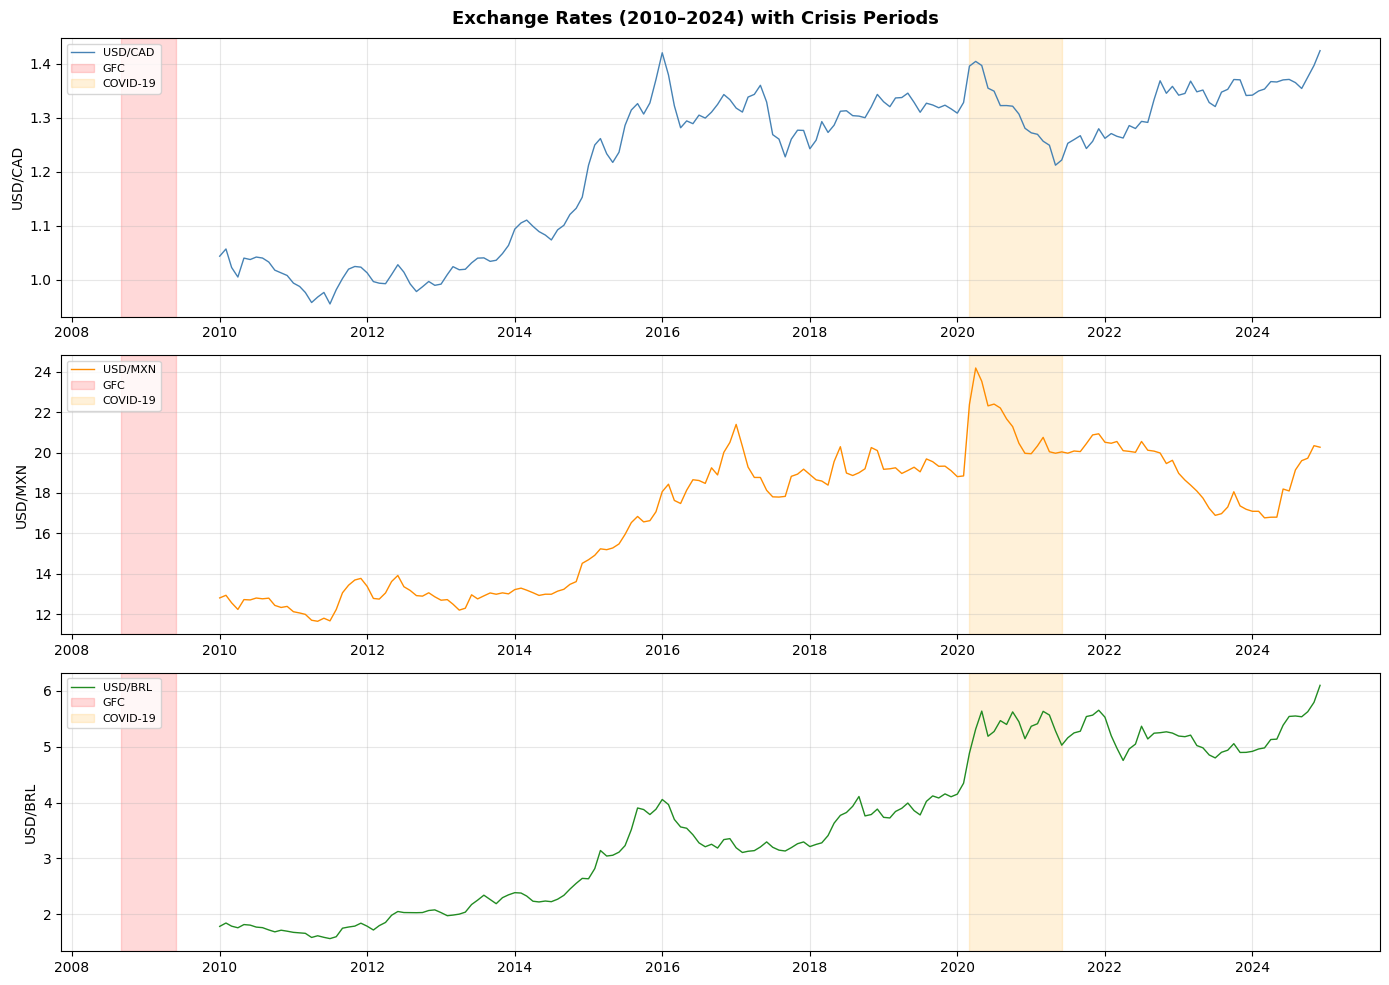

Figure saved: 14_fx_with_crises.png


In [16]:
# --- 7.3 Visualize outliers in exchange rates and trade flows ---

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

fx_cols  = ['FX_USD_CAD', 'FX_USD_MXN', 'FX_USD_BRL']
colors   = ['steelblue', 'darkorange', 'forestgreen']
labels   = ['USD/CAD', 'USD/MXN', 'USD/BRL']

for ax, col, color, label in zip(axes, fx_cols, colors, labels):
    data = country_datasets['CAN'][col]
    ax.plot(data.index, data.values, color=color, linewidth=1.0, label=label)

    # Shade crisis periods
    ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-01'),
               alpha=0.15, color='red', label='GFC')
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
               alpha=0.15, color='orange', label='COVID-19')

    ax.set_ylabel(label, fontsize=10)
    ax.legend(loc='upper left', fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.3)

fig.suptitle('Exchange Rates (2010–2024) with Crisis Periods', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / '14_fx_with_crises.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: 14_fx_with_crises.png')

---

## 8. Transformations

### 8.1 Log transformation of trade flows

Trade flow values span very large ranges (billions of USD). Log transformation:
- Reduces skewness and heteroskedasticity
- Makes percentage changes more interpretable
- Stabilizes variance — standard in international trade econometrics

We apply `log(x + 1)` to avoid issues if any value is exactly zero.

In [17]:
# --- 8.1 Log-transform trade flow columns ---

trade_value_cols = [c for c in country_datasets['CAN'].columns
                    if 'exports' in c or 'imports' in c]

for iso in PARTNERS:
    df = country_datasets[iso]
    for col in trade_value_cols:
        if col in df.columns:
            # log1p = log(x + 1), safe for zero values
            df[f'log_{col}'] = np.log1p(df[col])
    country_datasets[iso] = df

log_cols = [c for c in country_datasets['CAN'].columns if c.startswith('log_')]
print(f'Log-transformed columns created: {len(log_cols)}')
for c in log_cols:
    print(f'  {c}')

Log-transformed columns created: 8
  log_exports_total
  log_exports_commodities
  log_exports_manufactured_goods
  log_exports_high-tech
  log_imports_total
  log_imports_commodities
  log_imports_manufactured_goods
  log_imports_high-tech


In [18]:
# --- 8.2 Stationarity testing (ADF test) ---

# ARIMA requires stationary series. We test the log-transformed trade flows
# with the Augmented Dickey-Fuller (ADF) test.
#
# H0 (null hypothesis): series has a unit root (non-stationary)
# H1 (alternative):     series is stationary
# We reject H0 if p-value < 0.05.

def adf_test(series: pd.Series, name: str) -> dict:
    """
    Run ADF test and return a summary dict.
    
    Args:
        series: Time series (no NaN)
        name: Label for display
    
    Returns:
        Dict with ADF statistic, p-value, and stationarity verdict
    """
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'series': name,
        'adf_stat': round(result[0], 4),
        'p_value': round(result[1], 4),
        'stationary': result[1] < 0.05
    }

# Run ADF on log-trade flows for all country pairs
adf_results = []
for iso in PARTNERS:
    df = country_datasets[iso]
    for col in ['log_exports_total', 'log_imports_total']:
        if col in df.columns:
            r = adf_test(df[col], f'{iso}_{col}')
            adf_results.append(r)

adf_df = pd.DataFrame(adf_results)
print('=== ADF Stationarity Tests — Log Trade Flows ===')
print(adf_df.to_string(index=False))
print()
n_nonstat = (~adf_df['stationary']).sum()
print(f'Non-stationary series: {n_nonstat}/{len(adf_df)}')
print('→ Non-stationary series will be first-differenced for ARIMA.')

=== ADF Stationarity Tests — Log Trade Flows ===
               series  adf_stat  p_value  stationary
CAN_log_exports_total   -2.0631   0.2596       False
CAN_log_imports_total   -1.4471   0.5595       False
MEX_log_exports_total   -1.5926   0.4873       False
MEX_log_imports_total   -0.1371   0.9456       False
BRA_log_exports_total   -2.5298   0.1084       False
BRA_log_imports_total   -2.1048   0.2426       False

Non-stationary series: 6/6
→ Non-stationary series will be first-differenced for ARIMA.


In [19]:
# --- 8.3 First differencing for ARIMA ---

# For ARIMA, we need stationary series.
# First differencing: diff_x[t] = x[t] - x[t-1]
# This removes the trend component and is equivalent to ARIMA(p,1,q).
#
# We create differenced versions of all log-trade columns.
# RF and LightGBM work directly with the log levels (they don't require stationarity).

for iso in PARTNERS:
    df = country_datasets[iso]
    for col in log_cols:
        if col in df.columns:
            df[f'diff_{col}'] = df[col].diff()  # first difference
    country_datasets[iso] = df

diff_cols = [c for c in country_datasets['CAN'].columns if c.startswith('diff_')]
print(f'First-differenced columns created: {len(diff_cols)}')

# Verify stationarity of differenced series
print()
print('=== ADF Tests — First-Differenced Log Trade Flows ===')
adf_diff = []
for iso in PARTNERS:
    df = country_datasets[iso]
    for col in ['diff_log_exports_total', 'diff_log_imports_total']:
        if col in df.columns:
            r = adf_test(df[col].dropna(), f'{iso}_{col}')
            adf_diff.append(r)

print(pd.DataFrame(adf_diff).to_string(index=False))

First-differenced columns created: 8

=== ADF Tests — First-Differenced Log Trade Flows ===
                    series  adf_stat  p_value  stationary
CAN_diff_log_exports_total   -3.9617   0.0016        True
CAN_diff_log_imports_total   -4.1231   0.0009        True
MEX_diff_log_exports_total   -3.6911   0.0042        True
MEX_diff_log_imports_total   -4.6773   0.0001        True
BRA_diff_log_exports_total   -7.6685   0.0000        True
BRA_diff_log_imports_total   -3.3303   0.0136        True


In [20]:
# --- 8.4 Min-Max scaling for RF and LightGBM ---

# RF and LightGBM are tree-based and do not strictly require scaling.
# However, we create a scaled version of the features so the models
# are easier to compare and SHAP values are on a consistent scale.
#
# We fit the scaler only on the TRAINING period to avoid data leakage.
# Training window: 2010-01 to 2021-12 (80% of 180 months ≈ 144 months)
# Test window:     2022-01 to 2024-12 (36 months)

TRAIN_END = '2021-12-31'
TEST_START = '2022-01-01'

# Only scale the feature columns (not the target trade flow columns)
# We will scale per-country dataset at model training time.
# Here we just store the column list for reference.

feature_cols_for_ml = features.columns.tolist() + ['dummy_gfc', 'dummy_covid']

print(f'Train period: {START[:7]} → {TRAIN_END[:7]}  ({len(pd.date_range(START, TRAIN_END, freq="MS"))} months)')
print(f'Test period:  {TEST_START[:7]} → {END[:7]}  ({len(pd.date_range(TEST_START, END, freq="MS"))} months)')
print(f'Total:        {len(pd.date_range(START, END, freq="MS"))} months')
print()
print(f'Feature columns for ML: {len(feature_cols_for_ml)}')
print('(Scaling will be applied per model during the Modeling phase)')

Train period: 2010-01 → 2021-12  (144 months)
Test period:  2022-01 → 2024-12  (36 months)
Total:        180 months

Feature columns for ML: 29
(Scaling will be applied per model during the Modeling phase)


---

## 9. Feature Engineering

We create additional predictors from the existing variables to help the models capture:

1. **Lags** — past values of exchange rates (delayed effects on trade)
2. **Moving averages** — trend and smoothed signals
3. **Percentage changes** — month-over-month returns
4. **Calendar features** — month of year, quarter (seasonality)

### Why lags?

Trade contracts are negotiated in advance. An exchange rate shock in month *t* may only fully affect trade flows in *t+3* or *t+6* — importers/exporters take time to adjust orders, shipping schedules, and hedging. Lags of t-1, t-3, t-6, and t-12 capture these delayed effects.

In [21]:
# --- 9.1 Exchange rate lags ---

# We create lags for the BILATERAL exchange rate (the key variable)
# and for REER_USA (which affects all partners).
# Lag windows: 1, 3, 6, 12 months.

LAG_WINDOWS = [1, 3, 6, 12]

# Columns to lag: bilateral FX + REER
lag_targets = ['FX_USD_CAD', 'FX_USD_MXN', 'FX_USD_BRL',
               'REER_USA', 'REER_CAN', 'REER_MEX', 'REER_BRA']

lag_cols_created = []
for iso in PARTNERS:
    df = country_datasets[iso]
    for col in lag_targets:
        if col in df.columns:
            for lag in LAG_WINDOWS:
                new_col = f'{col}_lag{lag}'
                df[new_col] = df[col].shift(lag)
                if new_col not in lag_cols_created:
                    lag_cols_created.append(new_col)
    country_datasets[iso] = df

print(f'Lag columns created per dataset: {len(lag_cols_created)}')
print('Examples:', lag_cols_created[:8])

Lag columns created per dataset: 28
Examples: ['FX_USD_CAD_lag1', 'FX_USD_CAD_lag3', 'FX_USD_CAD_lag6', 'FX_USD_CAD_lag12', 'FX_USD_MXN_lag1', 'FX_USD_MXN_lag3', 'FX_USD_MXN_lag6', 'FX_USD_MXN_lag12']


In [22]:
# --- 9.2 Moving averages (rolling means) ---

# Rolling means smooth out short-term volatility and help the model
# capture the medium-term trend in exchange rates.
# Windows: 3, 6, 12 months.

MA_WINDOWS = [3, 6, 12]

# Columns to compute moving averages for: bilateral FX rates
ma_targets = ['FX_USD_CAD', 'FX_USD_MXN', 'FX_USD_BRL']

for iso in PARTNERS:
    df = country_datasets[iso]
    for col in ma_targets:
        if col in df.columns:
            for window in MA_WINDOWS:
                df[f'{col}_ma{window}'] = df[col].rolling(window=window, min_periods=1).mean()
    country_datasets[iso] = df

ma_cols = [c for c in country_datasets['CAN'].columns if '_ma' in c]
print(f'Moving average columns created: {len(ma_cols)}')

Moving average columns created: 15


In [23]:
# --- 9.3 Percentage changes (month-over-month returns) ---

# Month-over-month % change in exchange rates: (FX[t] - FX[t-1]) / FX[t-1]
# This measures the monthly appreciation/depreciation of the currency.

pct_targets = ['FX_USD_CAD', 'FX_USD_MXN', 'FX_USD_BRL', 'REER_USA']

for iso in PARTNERS:
    df = country_datasets[iso]
    for col in pct_targets:
        if col in df.columns:
            df[f'{col}_pct'] = df[col].pct_change()
    country_datasets[iso] = df

pct_cols = [c for c in country_datasets['CAN'].columns if '_pct' in c]
print(f'Percentage change columns created: {len(pct_cols)}')

Percentage change columns created: 4

In [24]:
# --- 9.4 Calendar features ---

# Seasonal patterns in trade: Q4 (holiday season) often sees higher import volumes,
# agricultural exports peak at harvest time, etc.

for iso in PARTNERS:
    df = country_datasets[iso]
    df['month']   = df.index.month      # 1–12
    df['quarter'] = df.index.quarter    # 1–4
    df['year']    = df.index.year       # 2010–2024
    country_datasets[iso] = df

print('Calendar features added: month, quarter, year')

Calendar features added: month, quarter, year


---

## 10. Final Dataset Summary and Save

### 10.1 Final column count and NaN check

In [25]:
# --- 10.1 Final summary ---

print('=== Final Dataset Summary ===')
for iso, info in PARTNERS.items():
    df = country_datasets[iso]
    total_nan = df.isna().sum().sum()
    print(f'\n{iso} ({info["name"]})')
    print(f'  Shape:   {df.shape}')
    print(f'  Rows:    {len(df)}')
    print(f'  Columns: {len(df.columns)}')
    print(f'  NaN:     {total_nan}')

    # NaN breakdown (lags create leading NaN — expected)
    nan_by_col = df.isna().sum()
    nan_by_col = nan_by_col[nan_by_col > 0]
    if len(nan_by_col) > 0:
        print(f'  NaN columns ({len(nan_by_col)}):')
        for c, n in nan_by_col.items():
            print(f'    {c}: {n}')

=== Final Dataset Summary ===

CAN (Canada)
  Shape:   (180, 97)
  Rows:    180
  Columns: 97
  NaN:     166
  NaN columns (40):
    diff_log_exports_total: 1
    diff_log_exports_commodities: 1
    diff_log_exports_manufactured_goods: 1
    diff_log_exports_high-tech: 1
    diff_log_imports_total: 1
    diff_log_imports_commodities: 1
    diff_log_imports_manufactured_goods: 1
    diff_log_imports_high-tech: 1
    FX_USD_CAD_lag1: 1
    FX_USD_CAD_lag3: 3
    FX_USD_CAD_lag6: 6
    FX_USD_CAD_lag12: 12
    FX_USD_MXN_lag1: 1
    FX_USD_MXN_lag3: 3
    FX_USD_MXN_lag6: 6
    FX_USD_MXN_lag12: 12
    FX_USD_BRL_lag1: 1
    FX_USD_BRL_lag3: 3
    FX_USD_BRL_lag6: 6
    FX_USD_BRL_lag12: 12
    REER_USA_lag1: 1
    REER_USA_lag3: 3
    REER_USA_lag6: 6
    REER_USA_lag12: 12
    REER_CAN_lag1: 1
    REER_CAN_lag3: 3
    REER_CAN_lag6: 6
    REER_CAN_lag12: 12
    REER_MEX_lag1: 1
    REER_MEX_lag3: 3
    REER_MEX_lag6: 6
    REER_MEX_lag12: 12
    REER_BRA_lag1: 1
    REER_BRA_lag3: 3
   

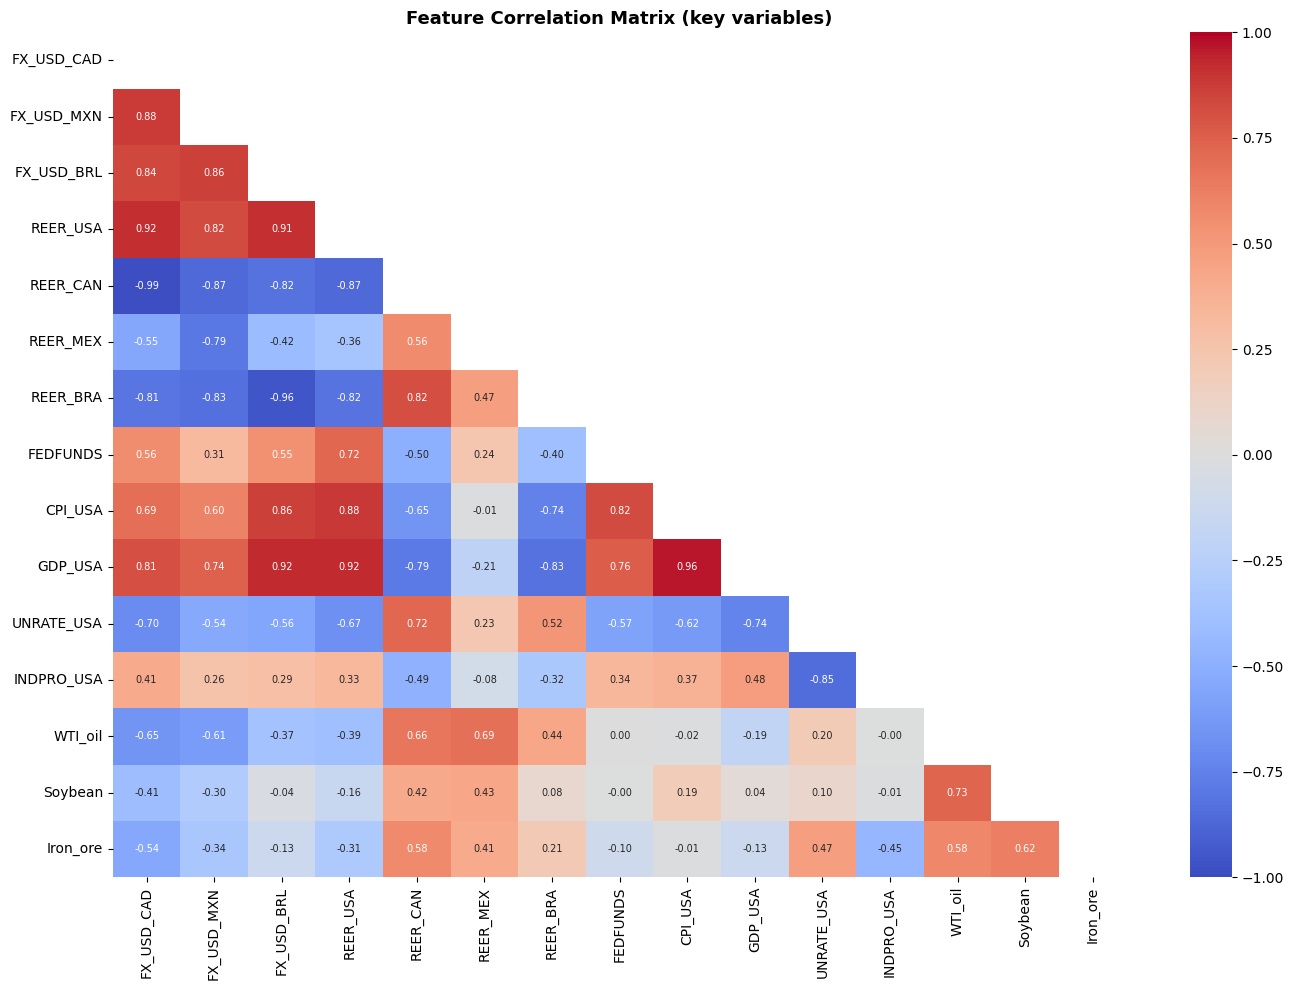

Figure saved: 15_correlation_matrix.png

High correlations (|r| > 0.85):
  FX_USD_MXN ↔ FX_USD_CAD: 0.879
  FX_USD_BRL ↔ FX_USD_MXN: 0.861
  REER_USA ↔ FX_USD_CAD: 0.918
  REER_USA ↔ FX_USD_BRL: 0.909
  REER_CAN ↔ FX_USD_CAD: -0.987
  REER_CAN ↔ FX_USD_MXN: -0.865
  REER_CAN ↔ REER_USA: -0.865
  REER_BRA ↔ FX_USD_BRL: -0.959
  CPI_USA ↔ FX_USD_BRL: 0.864
  CPI_USA ↔ REER_USA: 0.884
  GDP_USA ↔ FX_USD_BRL: 0.922
  GDP_USA ↔ REER_USA: 0.924
  GDP_USA ↔ CPI_USA: 0.962


In [26]:
# --- 10.2 Multicollinearity check (correlation matrix for key features) ---

# High correlation between features can hurt model interpretability.
# We compute pairwise correlations for the main exchange rate and macro features.

key_features = [
    'FX_USD_CAD', 'FX_USD_MXN', 'FX_USD_BRL',
    'REER_USA', 'REER_CAN', 'REER_MEX', 'REER_BRA',
    'FEDFUNDS', 'CPI_USA', 'GDP_USA', 'UNRATE_USA', 'INDPRO_USA',
    'WTI_oil', 'Soybean', 'Iron_ore'
]

corr_matrix = country_datasets['CAN'][key_features].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show only lower triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Feature Correlation Matrix (key variables)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / '15_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: 15_correlation_matrix.png')

# Flag high correlations (|r| > 0.85)
print()
print('High correlations (|r| > 0.85):')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

if high_corr:
    for a, b, r in high_corr:
        print(f'  {a} ↔ {b}: {r}')
else:
    print('  None above threshold.')

In [27]:
# --- 10.3 Save final datasets ---

# Save three country-pair datasets + one combined file

for iso, info in PARTNERS.items():
    df = country_datasets[iso]
    filename = PROC / f'dataset_{iso.lower()}.csv'
    df.to_csv(filename)
    print(f'Saved: {filename}  (shape: {df.shape})')

# Also save a combined file with a country identifier column
combined_parts = []
for iso in PARTNERS:
    df = country_datasets[iso].copy()
    df['country_pair'] = iso
    combined_parts.append(df)

df_combined = pd.concat(combined_parts)
df_combined.to_csv(PROC / 'dataset_combined.csv')
print(f'Saved: data/processed/dataset_combined.csv  (shape: {df_combined.shape})')

Saved: ..\data\processed\dataset_can.csv  (shape: (180, 97))
Saved: ..\data\processed\dataset_mex.csv  (shape: (180, 97))
Saved: ..\data\processed\dataset_bra.csv  (shape: (180, 97))
Saved: data/processed/dataset_combined.csv  (shape: (540, 98))


In [28]:
# --- 10.4 Pipeline documentation (column catalogue) ---

# Print a full catalogue of all columns in the final dataset
df_ref = country_datasets['CAN']

categories = {
    'Bilateral Exchange Rate':        [c for c in df_ref.columns if 'FX_USD' in c and 'lag' not in c and 'ma' not in c and 'pct' not in c],
    'REER':                           [c for c in df_ref.columns if 'REER' in c and 'lag' not in c],
    'US Macro':                       ['FEDFUNDS', 'CPI_USA', 'GDP_USA', 'UNRATE_USA', 'INDPRO_USA'],
    'Partner Interest Rates':         [c for c in df_ref.columns if c.startswith('RATE_')],
    'Partner CPI':                    [c for c in df_ref.columns if c.startswith('CPI_') and c != 'CPI_USA'],
    'Partner GDP':                    [c for c in df_ref.columns if c.startswith('GDP_') and c != 'GDP_USA'],
    'Partner Industrial Production':  [c for c in df_ref.columns if c.startswith('INDPRO_') and c != 'INDPRO_USA'],
    'Commodities':                    ['WTI_oil', 'Soybean', 'Iron_ore'],
    'Crisis Dummies':                 ['dummy_gfc', 'dummy_covid'],
    'Lags':                           [c for c in df_ref.columns if 'lag' in c],
    'Moving Averages':                [c for c in df_ref.columns if '_ma' in c],
    'Percentage Changes':             [c for c in df_ref.columns if '_pct' in c],
    'Calendar':                       ['month', 'quarter', 'year'],
    'Target — Log Levels':            [c for c in df_ref.columns if c.startswith('log_')],
    'Target — First Differences':     [c for c in df_ref.columns if c.startswith('diff_')],
    'Target — Raw Values':            [c for c in df_ref.columns if 'exports' in c or 'imports' in c]
}

print('=== Column Catalogue — Final Dataset ===')
total = 0
for cat, cols in categories.items():
    valid_cols = [c for c in cols if c in df_ref.columns]
    total += len(valid_cols)
    print(f'\n{cat} ({len(valid_cols)} columns):')
    for c in valid_cols:
        print(f'  {c}')

print(f'\nTotal columns in dataset: {len(df_ref.columns)}')
print(f'Data Preparation complete. Datasets saved to data/processed/')

=== Column Catalogue — Final Dataset ===

Bilateral Exchange Rate (3 columns):
  FX_USD_CAD
  FX_USD_MXN
  FX_USD_BRL

REER (5 columns):
  REER_USA
  REER_CAN
  REER_MEX
  REER_BRA
  REER_USA_pct

US Macro (5 columns):
  FEDFUNDS
  CPI_USA
  GDP_USA
  UNRATE_USA
  INDPRO_USA

Partner Interest Rates (3 columns):
  RATE_CAN
  RATE_MEX_3M
  RATE_BRA

Partner CPI (3 columns):
  CPI_CAN
  CPI_MEX
  CPI_BRA

Partner GDP (3 columns):
  GDP_CAN
  GDP_MEX
  GDP_BRA

Partner Industrial Production (3 columns):
  INDPRO_CAN
  INDPRO_MEX
  INDPRO_BRA

Commodities (3 columns):
  WTI_oil
  Soybean
  Iron_ore

Crisis Dummies (2 columns):
  dummy_gfc
  dummy_covid

Lags (28 columns):
  FX_USD_CAD_lag1
  FX_USD_CAD_lag3
  FX_USD_CAD_lag6
  FX_USD_CAD_lag12
  FX_USD_MXN_lag1
  FX_USD_MXN_lag3
  FX_USD_MXN_lag6
  FX_USD_MXN_lag12
  FX_USD_BRL_lag1
  FX_USD_BRL_lag3
  FX_USD_BRL_lag6
  FX_USD_BRL_lag12
  REER_USA_lag1
  REER_USA_lag3
  REER_USA_lag6
  REER_USA_lag12
  REER_CAN_lag1
  REER_CAN_lag3
  REER_C

---

## Summary

| Step | Action | Result |
|------|--------|--------|
| 1 | Load raw data | 10 files loaded |
| 2 | Frequency alignment | Daily/quarterly → monthly |
| 3 | Variable selection | 34 base features confirmed |
| 4 | Trade flows | Monthly totals + sectoral estimates (proportion method) |
| 5 | Integration | 3 country-pair DataFrames (180 months each) |
| 6 | Cleaning | ffill + bfill; temporal integrity validated |
| 7 | Outlier dummies | GFC (Sep 2008–Jun 2009) and COVID-19 (Mar 2020–Jun 2021) |
| 8 | Transformations | log1p, first differences, min-max scaling (deferred to modeling) |
| 9 | Feature engineering | Lags (1,3,6,12), MA (3,6,12), %change, calendar |
| 10 | Save | `data/processed/dataset_{can,mex,bra}.csv` + `dataset_combined.csv` |

**Next phase:** Modeling — `04_modeling.ipynb`